# Spektrální Embedding (Spectral Embedding)

## Co je Spektrální Embedding?

Spektrální Embedding (také známý jako Laplaciánské vlastní mapování) je nelineární metoda redukce dimenzionality, která využívá vlastních vektorů Laplaciánu grafu podobnosti dat. Tato technika je založena na spektrální teorii grafů a je obzvláště užitečná pro odhalení nelineárních struktur v datech.

### Klíčové vlastnosti Spektrálního Embeddingu:

- **Nelineární redukce**: Na rozdíl od PCA dokáže zachytit nelineární vztahy v datech
- **Zachování lokální struktury**: Důraz na zachování vzdáleností mezi blízkými body
- **Grafově založený přístup**: Modeluje data jako graf, kde vrcholy jsou datové body
- **Lokální perspektiva**: Zaměřuje se na lokální sousedství bodů spíše než na globální rozptyl

### Kdy použít Spektrální Embedding:

1. **Nelineární data**: Když data leží na nebo v blízkosti nelineární variety (manifold)
2. **Vizualizace komplexních dat**: Pro vizualizaci dat s nelineárními vztahy
3. **Lokální struktura**: Když je důležité zachovat lokální strukturu dat
4. **Předzpracování pro shlukování**: Jako krok před aplikací shlukovacích algoritmů

V scikit-learn je Spektrální Embedding implementován ve třídě `SpectralEmbedding` v modulu `sklearn.manifold`.

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_swiss_roll, make_s_curve, load_digits, fetch_olivetti_faces, load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time
from mpl_toolkits.mplot3d import Axes3D
import warnings

# Pro lepší vizualizaci
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. Základní použití Spektrálního Embeddingu

Začneme s demonstrací základního použití Spektrálního Embeddingu na syntetických datech, která mají výraznou nelineární strukturu.

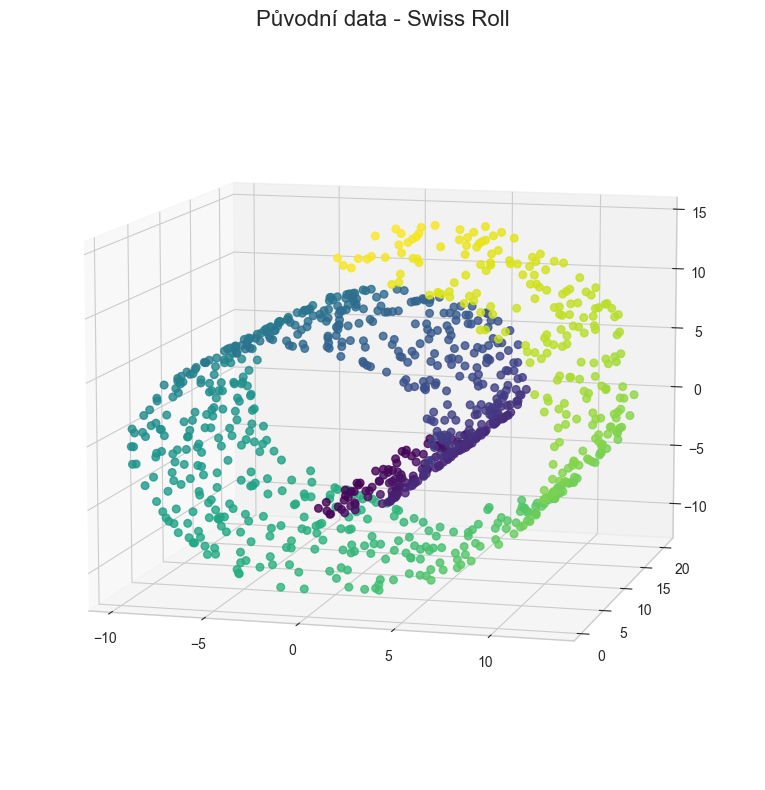

In [2]:
# Vytvoření syntetických dat - Swiss Roll (Švýcarský závin)
n_samples = 1000
noise = 0.05
X_swiss, color_swiss = make_swiss_roll(n_samples=n_samples, noise=noise, random_state=42)

# Vizualizace původních 3D dat
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=30, alpha=0.8)
ax.set_title('Původní data - Swiss Roll', fontsize=16)
ax.view_init(elev=10, azim=-75)  # Nastavení pohledu
plt.tight_layout()
plt.show()

Doba výpočtu Spektrálního Embeddingu: 0.0631 sekund


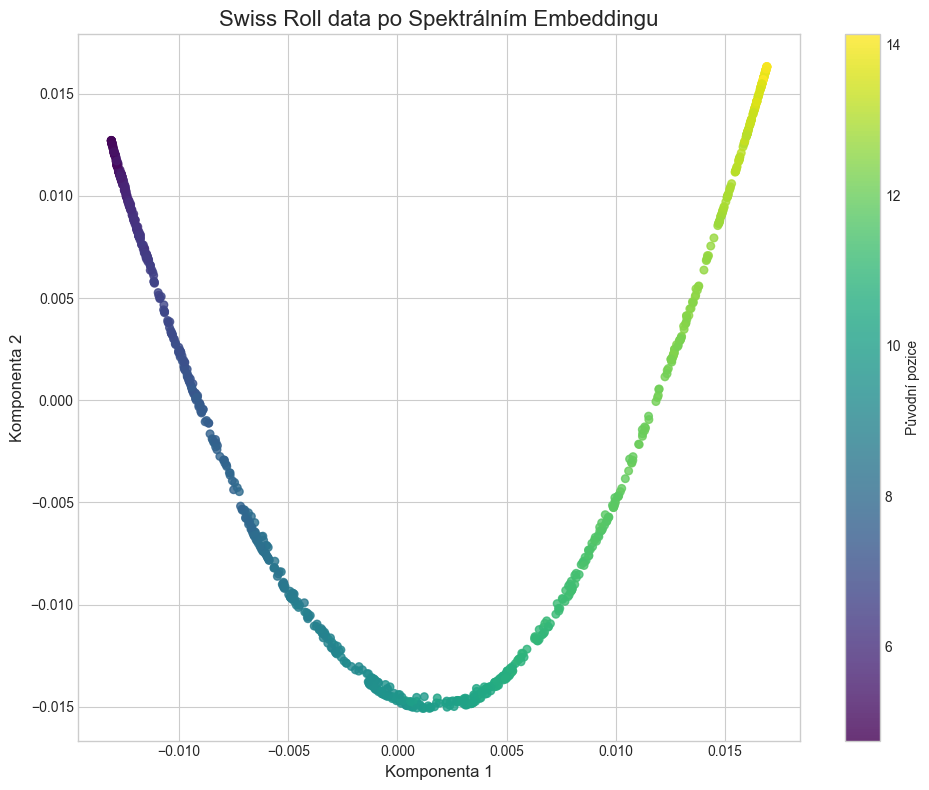

In [3]:
# Aplikace Spektrálního Embeddingu
start_time = time.time()
embedding = SpectralEmbedding(n_components=2, 
                             affinity='nearest_neighbors',
                             n_neighbors=10,
                             random_state=42)
X_se_swiss = embedding.fit_transform(X_swiss)
se_time = time.time() - start_time

print(f"Doba výpočtu Spektrálního Embeddingu: {se_time:.4f} sekund")

# Vizualizace výsledků Spektrálního Embeddingu
plt.figure(figsize=(10, 8))
plt.scatter(X_se_swiss[:, 0], X_se_swiss[:, 1], c=color_swiss, cmap='viridis', s=30, alpha=0.8)
plt.colorbar(label='Původní pozice')
plt.title('Swiss Roll data po Spektrálním Embeddingu', fontsize=16)
plt.xlabel('Komponenta 1', fontsize=12)
plt.ylabel('Komponenta 2', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

PCA: 0.0030 sekund
Spektrální Embedding: 0.0575 sekund
t-SNE: 5.4607 sekund
Isomap: 0.3597 sekund
LLE: 0.0806 sekund


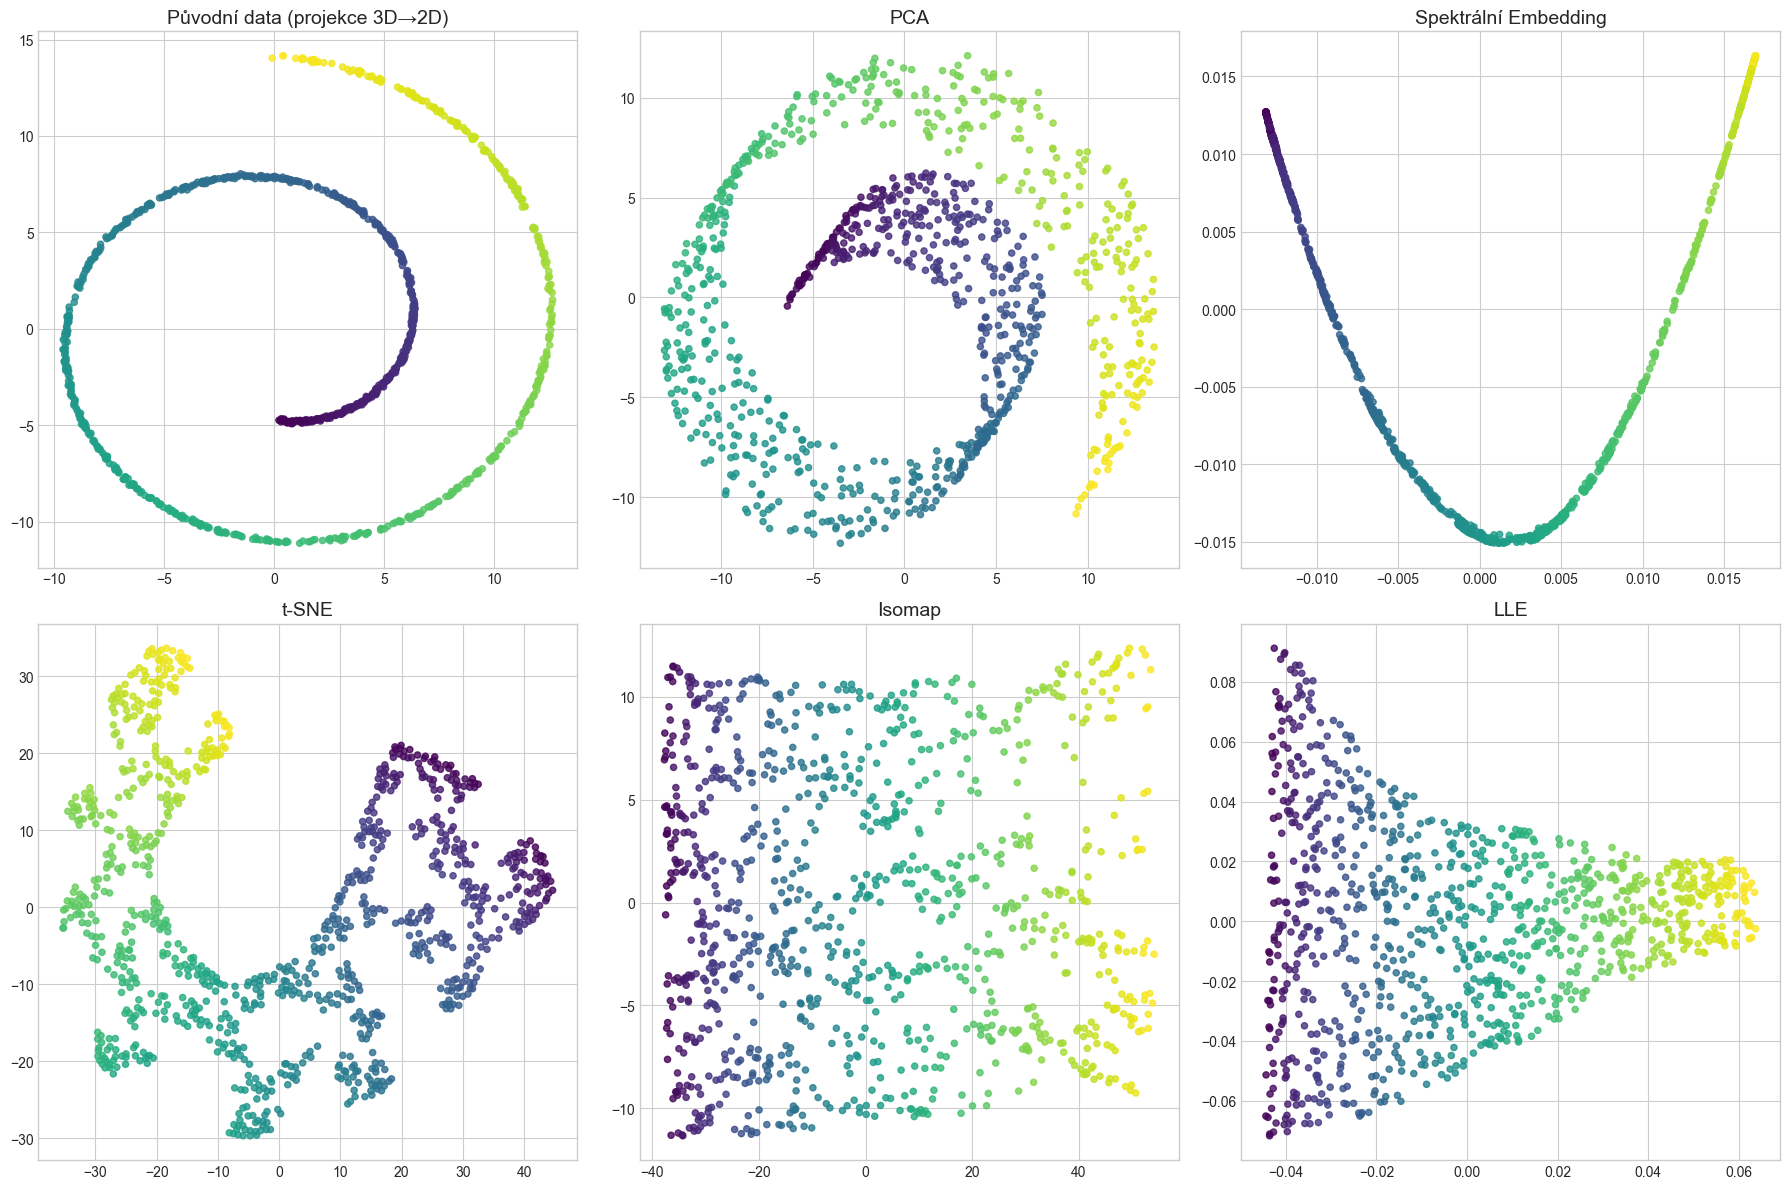

In [4]:
# Porovnání s jinými nelineárními metodami redukce dimenzionality
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding
from sklearn.decomposition import PCA

# Inicializace různých metod
methods = {
    'PCA': PCA(n_components=2, random_state=42),
    'Spektrální Embedding': SpectralEmbedding(n_components=2, 
                                            affinity='nearest_neighbors',
                                            n_neighbors=10, 
                                            random_state=42),
    't-SNE': TSNE(n_components=2, random_state=42),
    'Isomap': Isomap(n_components=2, n_neighbors=10),
    'LLE': LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
}

# Aplikace metod a měření času
results = {}
for name, method in methods.items():
    start_time = time.time()
    results[name] = method.fit_transform(X_swiss)
    elapsed = time.time() - start_time
    print(f"{name}: {elapsed:.4f} sekund")

# Vizualizace výsledků všech metod
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Původní 3D data zobrazená v 2D
axes[0].scatter(X_swiss[:, 0], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Původní data (projekce 3D→2D)', fontsize=14)
axes[0].grid(True)

# Výsledky metod redukce dimenzionality
i = 1
for name, embedding in results.items():
    axes[i].scatter(embedding[:, 0], embedding[:, 1], c=color_swiss, cmap='viridis', s=20, alpha=0.8)
    axes[i].set_title(name, fontsize=14)
    axes[i].grid(True)
    i += 1

plt.tight_layout()
plt.show()

## 2. Vliv parametrů na Spektrální Embedding

Prozkoumáme, jak různé hodnoty klíčových parametrů ovlivňují výsledky Spektrálního Embeddingu.

n_neighbors=5: 0.1290 sekund
n_neighbors=10: 0.0761 sekund
n_neighbors=30: 0.1100 sekund
n_neighbors=50: 0.0986 sekund
n_neighbors=100: 0.1402 sekund


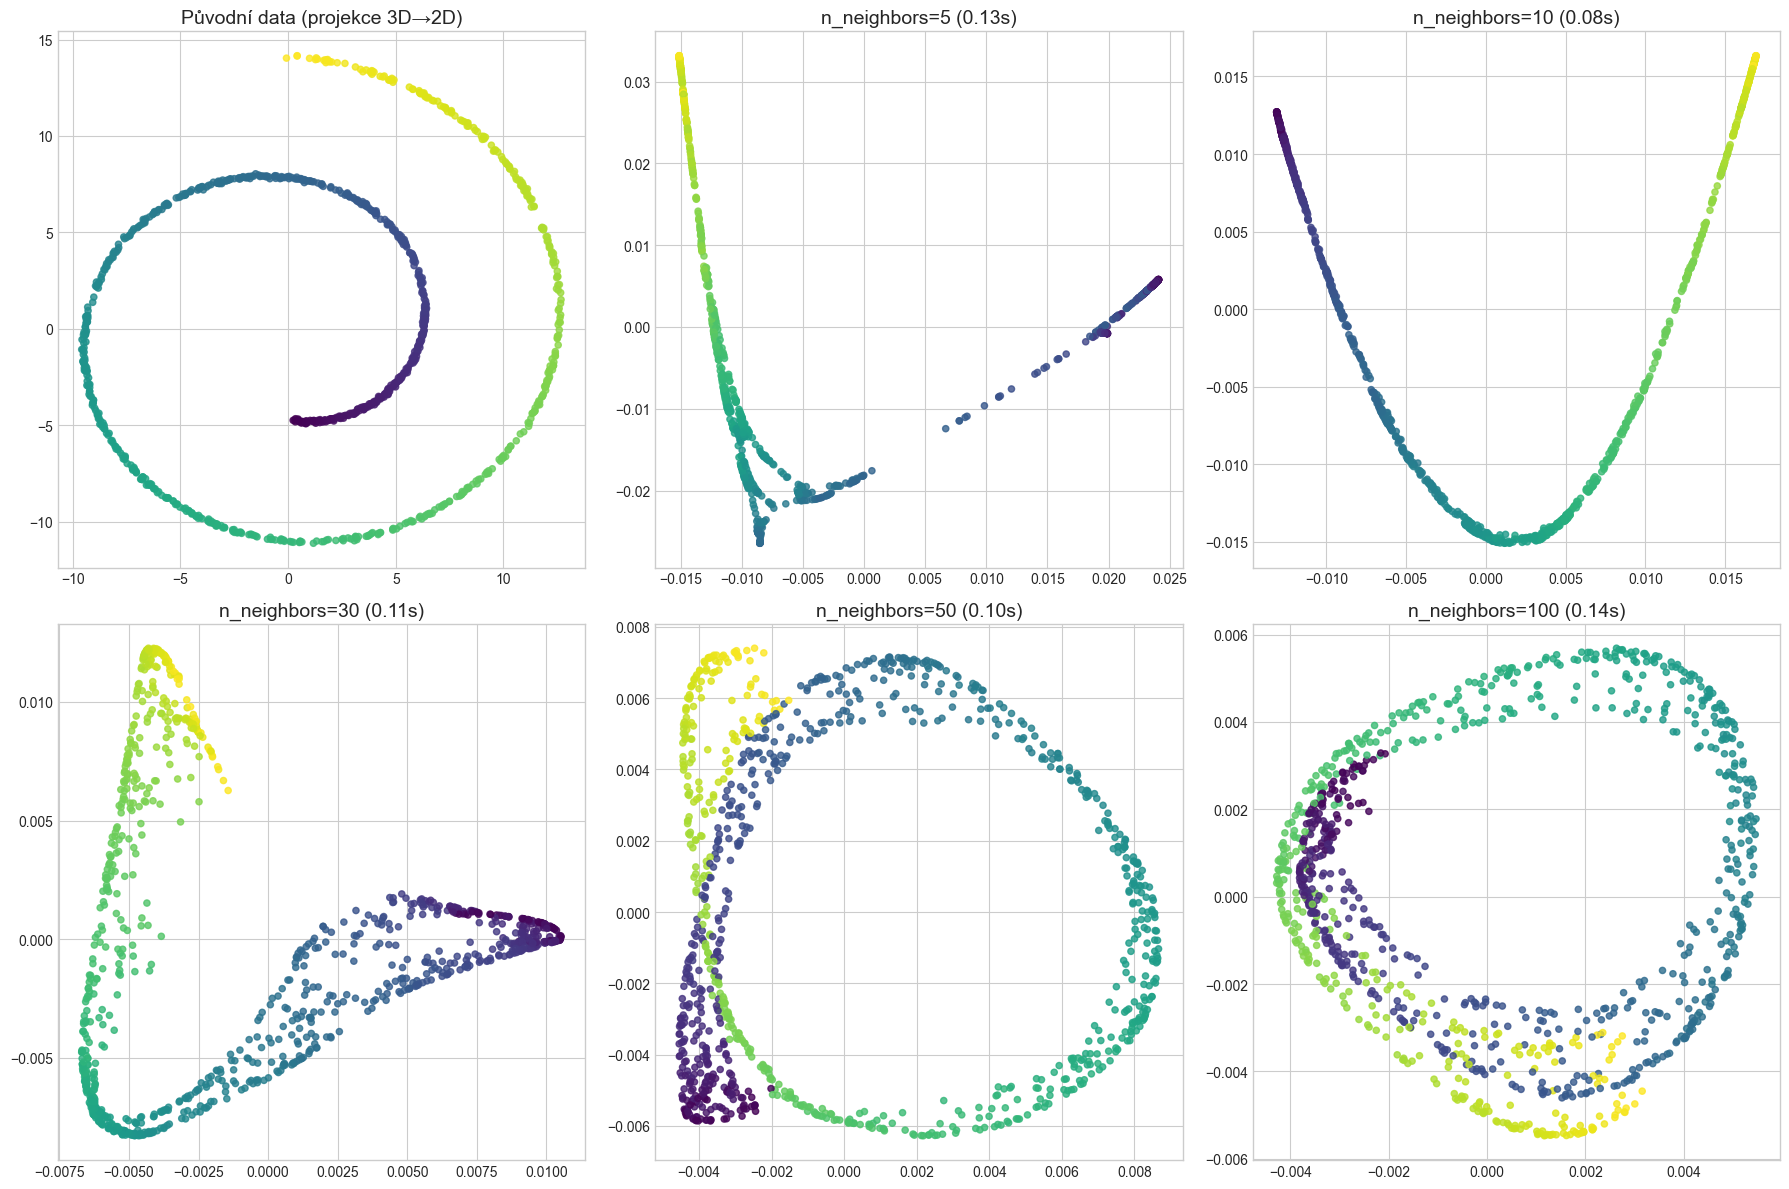

In [5]:
# 1. Vliv parametru n_neighbors
n_neighbors_list = [5, 10, 30, 50, 100]
neighbor_results = {}

for nn in n_neighbors_list:
    embedding = SpectralEmbedding(
        n_components=2,
        affinity='nearest_neighbors',
        n_neighbors=nn,
        random_state=42
    )
    start_time = time.time()
    X_embedded = embedding.fit_transform(X_swiss)
    elapsed = time.time() - start_time
    neighbor_results[nn] = {
        'embedding': X_embedded,
        'time': elapsed
    }
    print(f"n_neighbors={nn}: {elapsed:.4f} sekund")

# Vizualizace výsledků pro různý počet sousedů
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Původní data
axes[0].scatter(X_swiss[:, 0], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Původní data (projekce 3D→2D)', fontsize=14)
axes[0].grid(True)

# Výsledky pro různý počet sousedů
i = 1
for nn, result in neighbor_results.items():
    axes[i].scatter(result['embedding'][:, 0], result['embedding'][:, 1], 
                  c=color_swiss, cmap='viridis', s=20, alpha=0.8)
    axes[i].set_title(f'n_neighbors={nn} ({result["time"]:.2f}s)', fontsize=14)
    axes[i].grid(True)
    i += 1
    if i >= len(axes):
        break

plt.tight_layout()
plt.show()

affinity=nearest_neighbors: 0.1331 sekund
affinity=rbf: 0.2701 sekund


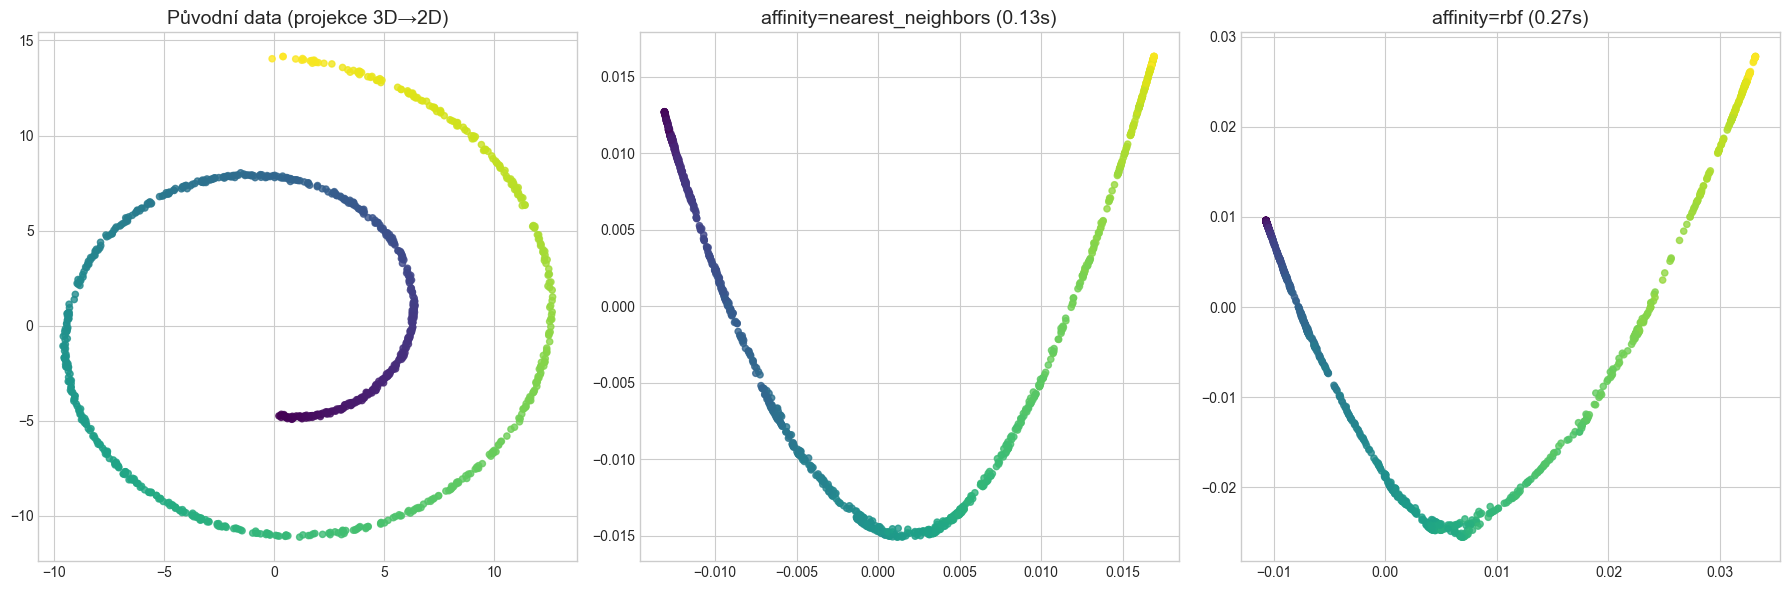

In [6]:
# 2. Vliv parametru affinity
affinity_list = ['nearest_neighbors', 'rbf']
affinity_results = {}

for affinity in affinity_list:
    # Pro 'rbf' nepotřebujeme n_neighbors
    kwargs = {'n_neighbors': 10} if affinity == 'nearest_neighbors' else {}
    
    embedding = SpectralEmbedding(
        n_components=2,
        affinity=affinity,
        random_state=42,
        **kwargs
    )
    start_time = time.time()
    X_embedded = embedding.fit_transform(X_swiss)
    elapsed = time.time() - start_time
    affinity_results[affinity] = {
        'embedding': X_embedded,
        'time': elapsed
    }
    print(f"affinity={affinity}: {elapsed:.4f} sekund")

# Vizualizace výsledků pro různé typy affinity
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Původní data
axes[0].scatter(X_swiss[:, 0], X_swiss[:, 2], c=color_swiss, cmap='viridis', s=20, alpha=0.8)
axes[0].set_title('Původní data (projekce 3D→2D)', fontsize=14)
axes[0].grid(True)

# Výsledky pro různé typy affinity
i = 1
for affinity, result in affinity_results.items():
    axes[i].scatter(result['embedding'][:, 0], result['embedding'][:, 1], 
                  c=color_swiss, cmap='viridis', s=20, alpha=0.8)
    axes[i].set_title(f'affinity={affinity} ({result["time"]:.2f}s)', fontsize=14)
    axes[i].grid(True)
    i += 1

plt.tight_layout()
plt.show()

## 3. Aplikace na S-křivku

Vyzkoušíme Spektrální Embedding na další typ syntetických dat - S-křivku.

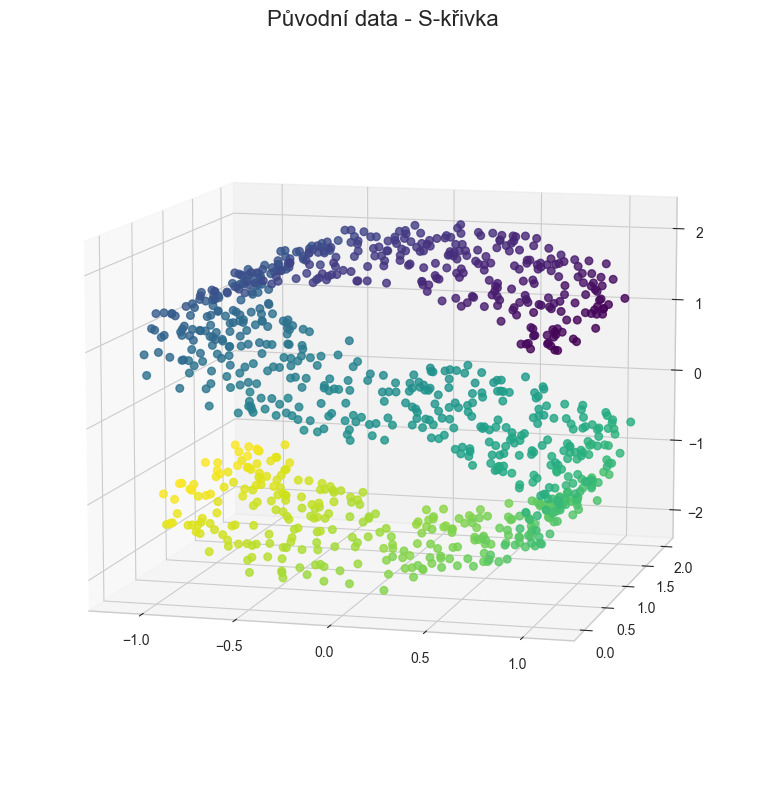

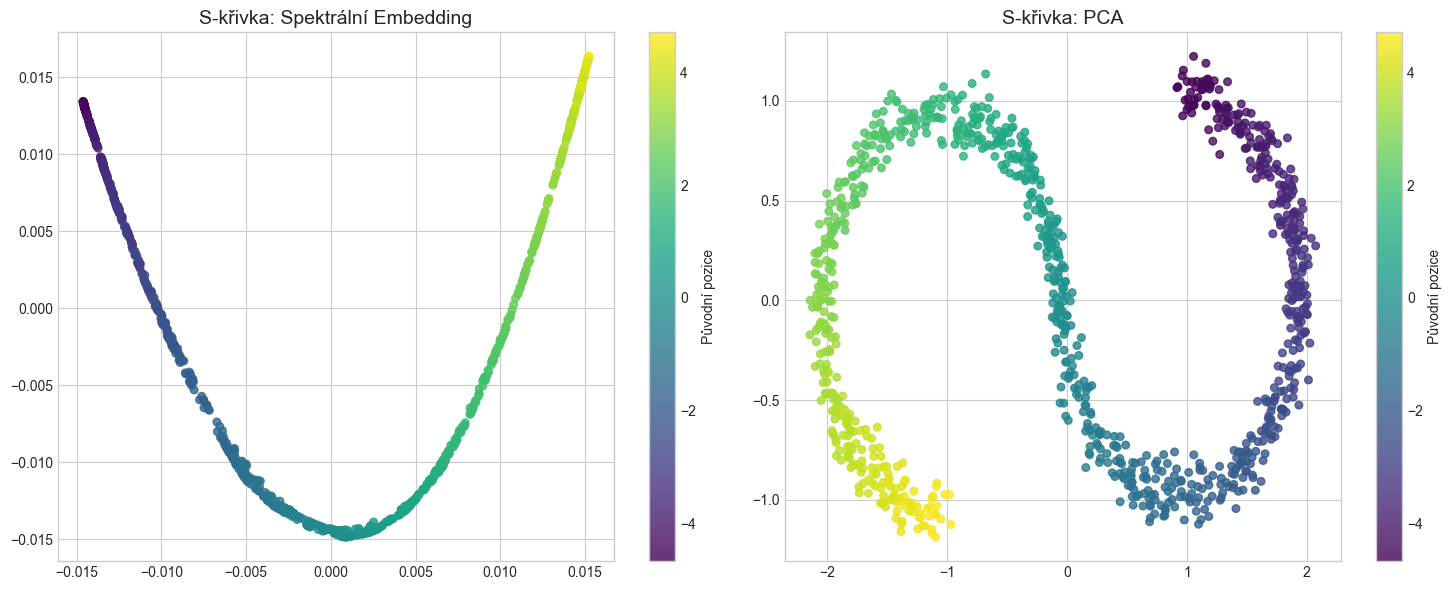

In [7]:
# Vytvoření S-křivky
X_s_curve, color_s_curve = make_s_curve(n_samples=n_samples, noise=noise, random_state=42)

# Vizualizace původních 3D dat
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s_curve[:, 0], X_s_curve[:, 1], X_s_curve[:, 2], 
         c=color_s_curve, cmap='viridis', s=30, alpha=0.8)
ax.set_title('Původní data - S-křivka', fontsize=16)
ax.view_init(elev=10, azim=-75)
plt.tight_layout()
plt.show()

# Aplikace Spektrálního Embeddingu na S-křivku
embedding = SpectralEmbedding(n_components=2, 
                            affinity='nearest_neighbors',
                            n_neighbors=10,
                            random_state=42)
X_se_s_curve = embedding.fit_transform(X_s_curve)

# Porovnání s PCA
pca = PCA(n_components=2, random_state=42)
X_pca_s_curve = pca.fit_transform(X_s_curve)

# Vizualizace výsledků
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_se_s_curve[:, 0], X_se_s_curve[:, 1], c=color_s_curve, cmap='viridis', s=30, alpha=0.8)
plt.colorbar(label='Původní pozice')
plt.title('S-křivka: Spektrální Embedding', fontsize=14)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_pca_s_curve[:, 0], X_pca_s_curve[:, 1], c=color_s_curve, cmap='viridis', s=30, alpha=0.8)
plt.colorbar(label='Původní pozice')
plt.title('S-křivka: PCA', fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Aplikace na reálná data - MNIST Digits

Aplikujeme Spektrální Embedding na reálná data - dataset ručně psaných číslic MNIST.

Tvar dat: (1797, 64)
Počet tříd: 10


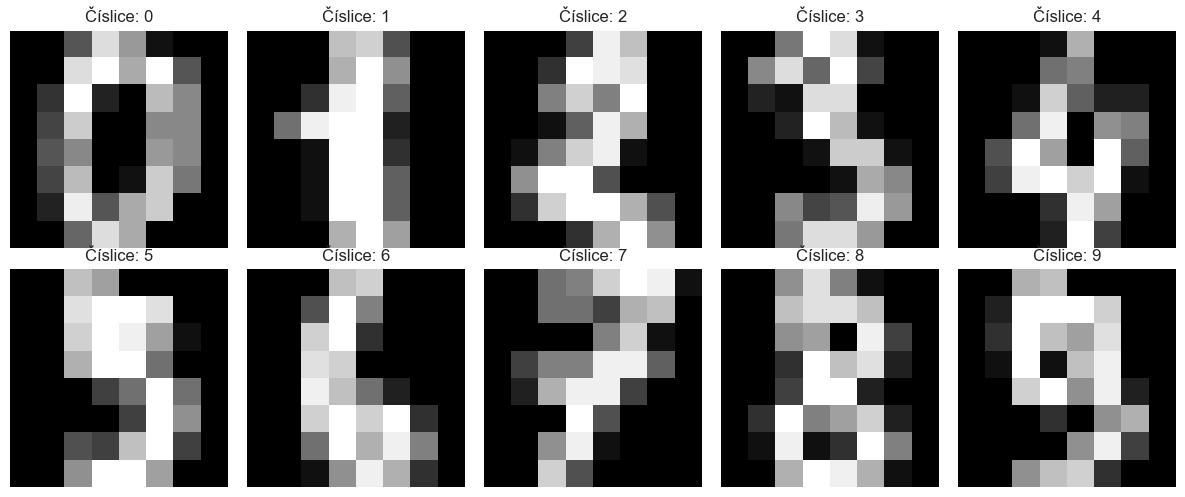

In [8]:
# Načtení datasetu MNIST Digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Tvar dat: {X_digits.shape}")
print(f"Počet tříd: {len(np.unique(y_digits))}")

# Zobrazení několika příkladů
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Číslice: {y_digits[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Pipeline pro standardizaci a Spektrální Embedding
se_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('embedding', SpectralEmbedding(n_components=2, 
                                  affinity='nearest_neighbors',
                                  n_neighbors=10,
                                  random_state=42))
])

# Aplikace na MNIST data
start_time = time.time()
X_se_digits = se_pipeline.fit_transform(X_digits)
se_digits_time = time.time() - start_time

print(f"Doba výpočtu Spektrálního Embeddingu pro MNIST: {se_digits_time:.4f} sekund")

# Pro porovnání aplikujeme také PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])

start_time = time.time()
X_pca_digits = pca_pipeline.fit_transform(X_digits)
pca_digits_time = time.time() - start_time

print(f"Doba výpočtu PCA pro MNIST: {pca_digits_time:.4f} sekund")

Doba výpočtu Spektrálního Embeddingu pro MNIST: 0.3127 sekund
Doba výpočtu PCA pro MNIST: 0.0041 sekund


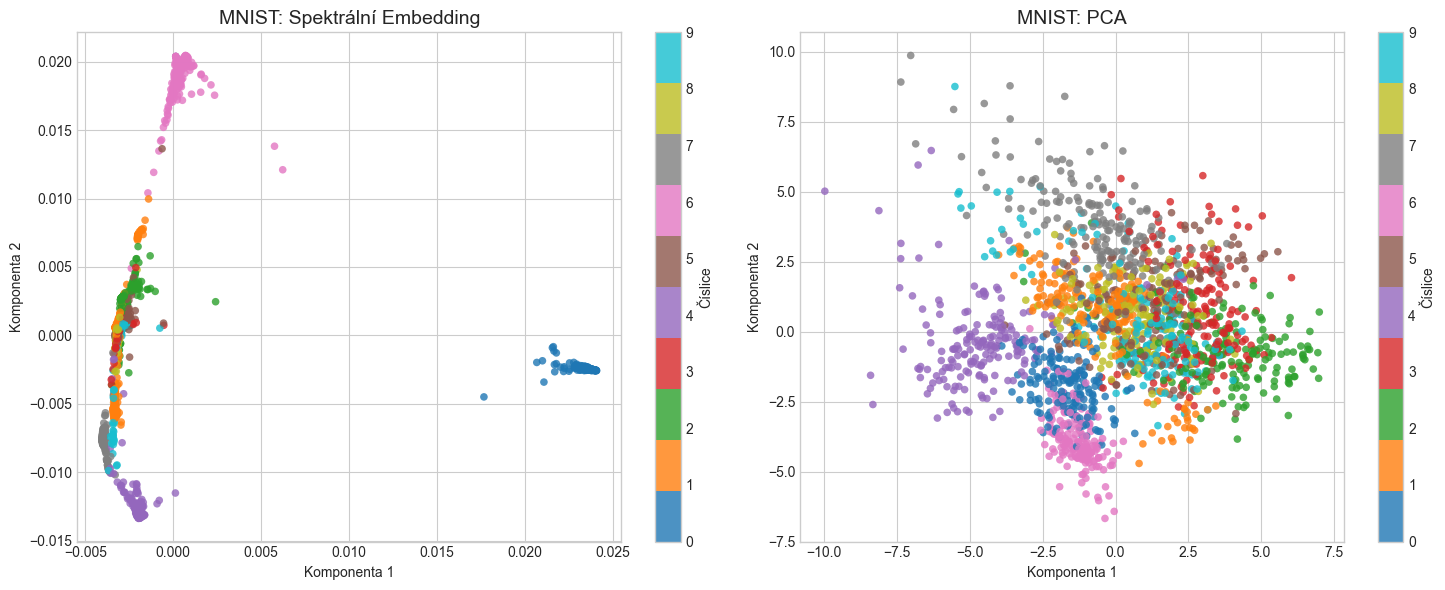

In [10]:
# Vizualizace výsledků pro MNIST
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_se_digits[:, 0], X_se_digits[:, 1], c=y_digits, cmap='tab10', 
                     alpha=0.8, s=30, edgecolor='none')
plt.colorbar(label='Číslice')
plt.title('MNIST: Spektrální Embedding', fontsize=14)
plt.xlabel('Komponenta 1')
plt.ylabel('Komponenta 2')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_pca_digits[:, 0], X_pca_digits[:, 1], c=y_digits, cmap='tab10', 
          alpha=0.8, s=30, edgecolor='none')
plt.colorbar(label='Číslice')
plt.title('MNIST: PCA', fontsize=14)
plt.xlabel('Komponenta 1')
plt.ylabel('Komponenta 2')
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Zhodnocení kvality redukce dimenzionality pro klasifikaci

Nyní porovnáme, jak dobře funguje klasifikace na datech redukovaných pomocí Spektrálního Embeddingu ve srovnání s jinými metodami.

Výsledky klasifikace po redukci dimenzionality:
                 Metoda   Klasifikátor  Dimenze  Přesnost  Doba trénování [s]  \
0          Původní data            KNN       64    0.9759              0.0010   
1          Původní data  Random Forest       64    0.9741              0.3651   
2                   PCA            KNN        2    0.5333              0.0010   
3                   PCA  Random Forest        2    0.5259              0.2959   
4  Spektrální Embedding            KNN        2    0.0574              0.0010   
5  Spektrální Embedding  Random Forest        2    0.1148              0.2612   
6                Isomap            KNN        2    0.7019              0.0010   
7                Isomap  Random Forest        2    0.6722              0.2666   
8                 t-SNE            KNN        2    0.0296              0.0010   
9                 t-SNE  Random Forest        2    0.0463              0.2415   

   Doba predikce [s]  
0             0.0040  
1             

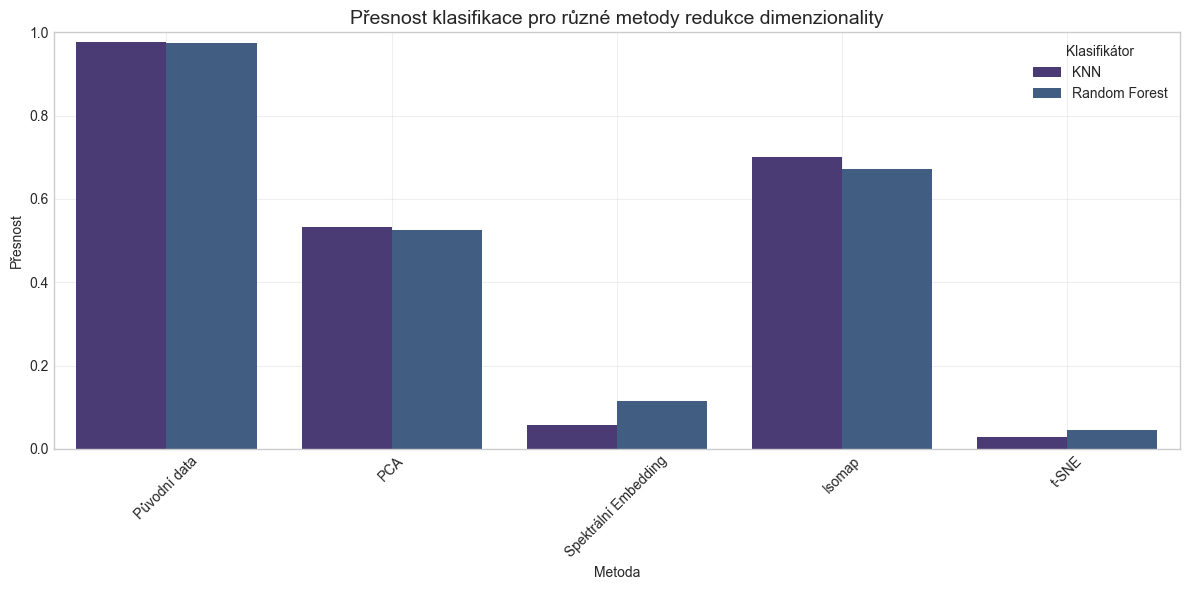

In [11]:
# Připravíme různé metody redukce dimenzionality
reduction_methods = {
    'Původní data': None,
    'PCA': PCA(n_components=2, random_state=42),
    'Spektrální Embedding': SpectralEmbedding(n_components=2, n_neighbors=10, random_state=42),
    'Isomap': Isomap(n_components=2, n_neighbors=10),
    't-SNE': TSNE(n_components=2, random_state=42)
}

# Připravíme klasifikátory
classifiers = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Rozdělení na trénovací a testovací sadu
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Výsledky klasifikace
results = []

# Pro každou metodu redukce dimenzionality
for method_name, reducer in reduction_methods.items():
    if reducer is None:
        # Původní data bez redukce
        X_train_reduced = X_train_scaled
        X_test_reduced = X_test_scaled
        dim = X_train_scaled.shape[1]
    else:
        # Aplikace redukce dimenzionality
        start_time = time.time()
        X_train_reduced = reducer.fit_transform(X_train_scaled)
        X_test_reduced = reducer.transform(X_test_scaled) if hasattr(reducer, 'transform') else reducer.fit_transform(X_test_scaled)
        reduction_time = time.time() - start_time
        dim = X_train_reduced.shape[1]
    
    # Pro každý klasifikátor
    for clf_name, clf in classifiers.items():
        start_time = time.time()
        clf.fit(X_train_reduced, y_train)
        train_time = time.time() - start_time
        
        start_time = time.time()
        y_pred = clf.predict(X_test_reduced)
        pred_time = time.time() - start_time
        
        accuracy = accuracy_score(y_test, y_pred)
        
        results.append({
            'Metoda': method_name,
            'Klasifikátor': clf_name,
            'Dimenze': dim,
            'Přesnost': accuracy,
            'Doba trénování [s]': train_time,
            'Doba predikce [s]': pred_time
        })

# Převedení výsledků na DataFrame
results_df = pd.DataFrame(results)
print("Výsledky klasifikace po redukci dimenzionality:")
print(results_df.round(4))

# Vizualizace výsledků
plt.figure(figsize=(12, 6))
sns.barplot(x='Metoda', y='Přesnost', hue='Klasifikátor', data=results_df)
plt.title('Přesnost klasifikace pro různé metody redukce dimenzionality', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Použití Spektrálního Embeddingu na Iris dataset

Vyzkoušíme Spektrální Embedding také na známém datasetu Iris.

Tvar dat: (150, 4)
Počet tříd: 3
Cílové třídy: ['setosa' 'versicolor' 'virginica']


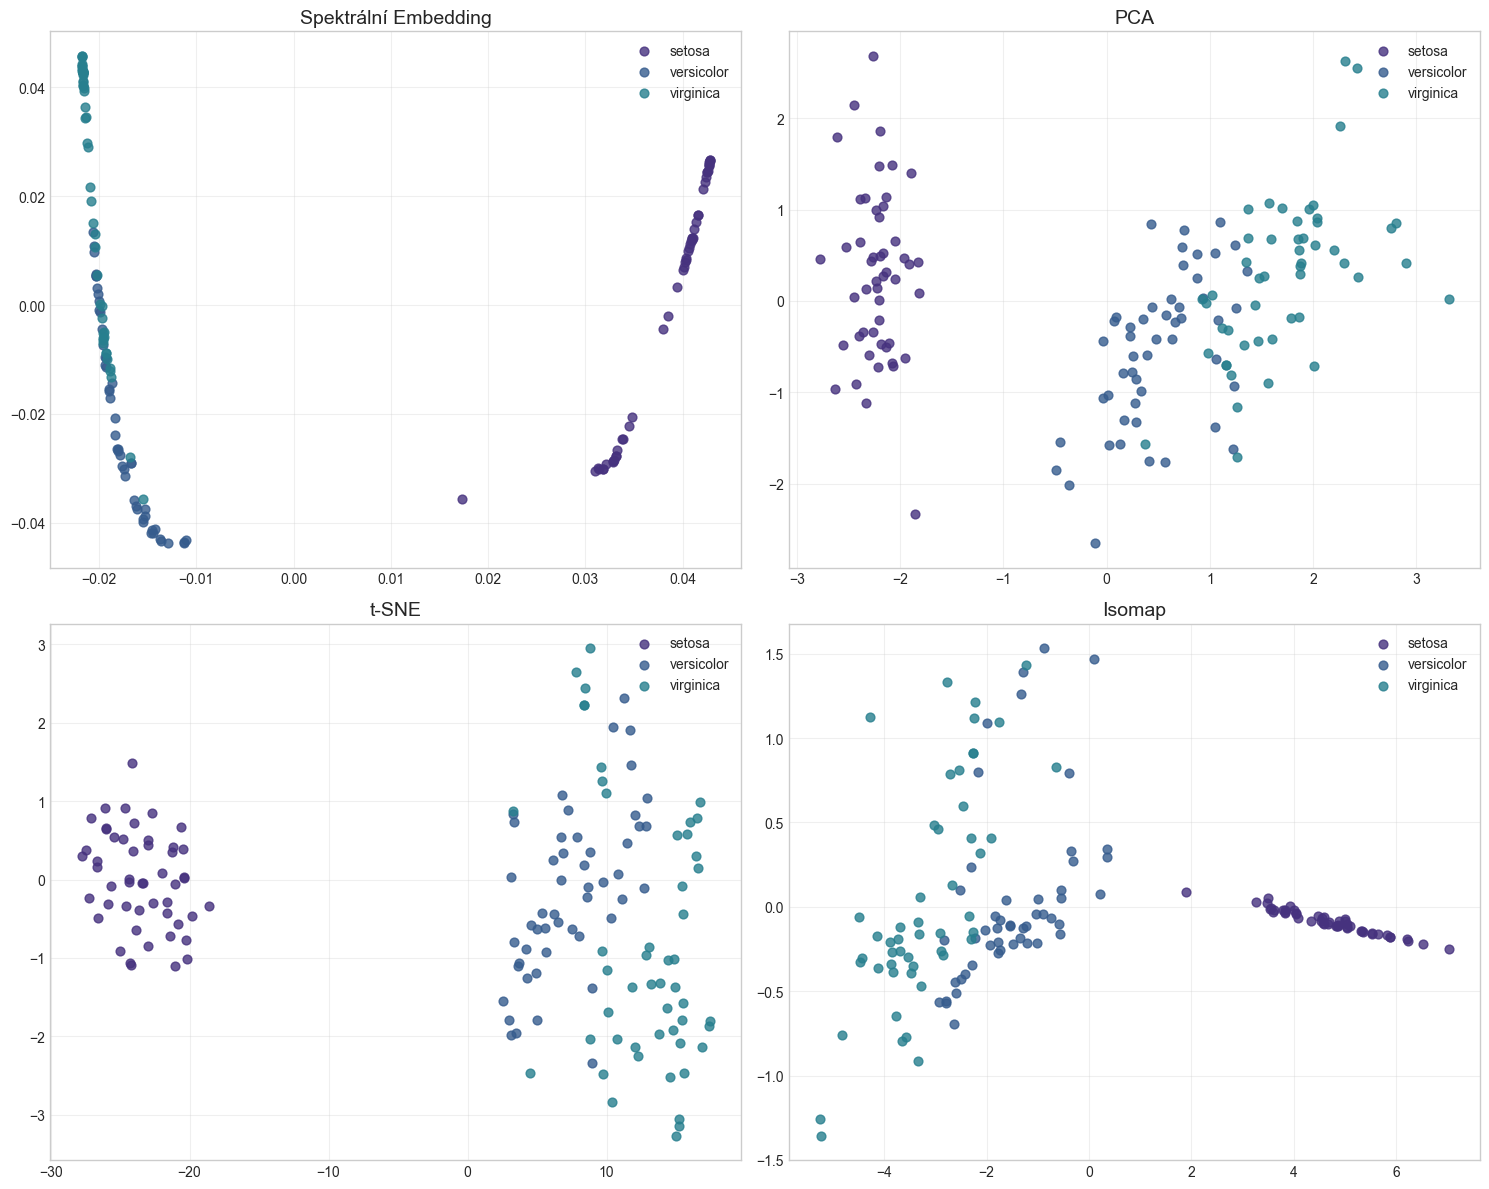

In [12]:
# Načtení datasetu Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

print(f"Tvar dat: {X_iris.shape}")
print(f"Počet tříd: {len(np.unique(y_iris))}")
print(f"Cílové třídy: {target_names}")

# Aplikace Spektrálního Embeddingu na Iris
se_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('embedding', SpectralEmbedding(n_components=2, 
                                  affinity='nearest_neighbors',
                                  n_neighbors=10,
                                  random_state=42))
])

X_se_iris = se_pipeline.fit_transform(X_iris)

# Porovnání s jinými metodami
methods = {
    'PCA': PCA(n_components=2, random_state=42),
    't-SNE': TSNE(n_components=2, random_state=42),
    'Isomap': Isomap(n_components=2, n_neighbors=10)
}

# Příprava výsledků pro různé metody
iris_results = {'Spektrální Embedding': X_se_iris}
for name, method in methods.items():
    pipeline = Pipeline([('scaler', StandardScaler()), ('reducer', method)])
    iris_results[name] = pipeline.fit_transform(X_iris)

# Vizualizace výsledků všech metod
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, embedding) in enumerate(iris_results.items()):
    for j, (c, label) in enumerate(zip(range(3), target_names)):
        axes[i].scatter(embedding[y_iris == j, 0], embedding[y_iris == j, 1],
                      label=label, s=40, alpha=0.8)
    axes[i].set_title(name, fontsize=14)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Analýza časové složitosti Spektrálního Embeddingu

Prozkoumáme, jak se mění výpočetní čas Spektrálního Embeddingu s rostoucí velikostí datové sady.

In [13]:
# # Vytvoření syntetických datových sad různých velikostí
# sample_sizes = [100, 500, 1000, 2000, 3000]
# n_features = 20  # Počet příznaků
# n_clusters = 3   # Počet shluků

# times_spectral = []
# times_pca = []
# times_tsne = []

# for n_samples in sample_sizes:
#     # Vytvoření dat
#     X, _ = make_blobs(n_samples=n_samples, n_features=n_features, 
#                     centers=n_clusters, random_state=42)
    
#     # Měření času pro Spektrální Embedding
#     start_time = time.time()
#     SpectralEmbedding(n_components=2, random_state=42).fit_transform(X)
#     spectral_time = time.time() - start_time
#     times_spectral.append(spectral_time)
    
#     # Měření času pro PCA
#     start_time = time.time()
#     PCA(n_components=2, random_state=42).fit_transform(X)
#     pca_time = time.time() - start_time
#     times_pca.append(pca_time)
    
#     # Měření času pro t-SNE
#     start_time = time.time()
#     TSNE(n_components=2, random_state=42).fit_transform(X)
#     tsne_time = time.time() - start_time
#     times_tsne.append(tsne_time)
    
#     print(f"Velikost vzorku: {n_samples}, "
#           f"Spektrální Embedding: {spectral_time:.4f}s, "
#           f"PCA: {pca_time:.4f}s, "
#           f"t-SNE: {tsne_time:.4f}s")

# # Vizualizace výsledků
# plt.figure(figsize=(12, 6))
# plt.plot(sample_sizes, times_spectral, 'o-', linewidth=2, label='Spektrální Embedding')
# plt.plot(sample_sizes, times_pca, 'x-', linewidth=2, label='PCA')
# plt.plot(sample_sizes, times_tsne, 's-', linewidth=2, label='t-SNE')
# plt.xlabel('Počet vzorků', fontsize=12)
# plt.ylabel('Doba výpočtu [s]', fontsize=12)
# plt.title('Škálování výpočetního času s velikostí datové sady', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend(fontsize=12)
# plt.tight_layout()
# plt.show()

```
NameError: name 'make_blobs' is not defined
```

Velikost vzorku: 100, Spektrální Embedding: 0.0070s, PCA: 0.0010s, t-SNE: 0.4181s
Velikost vzorku: 500, Spektrální Embedding: 0.0235s, PCA: 0.0010s, t-SNE: 1.9230s
Velikost vzorku: 1000, Spektrální Embedding: 0.0785s, PCA: 0.0010s, t-SNE: 4.5323s
Velikost vzorku: 2000, Spektrální Embedding: 0.3831s, PCA: 0.0010s, t-SNE: 11.1931s
Velikost vzorku: 3000, Spektrální Embedding: 0.9068s, PCA: 0.0020s, t-SNE: 18.9975s


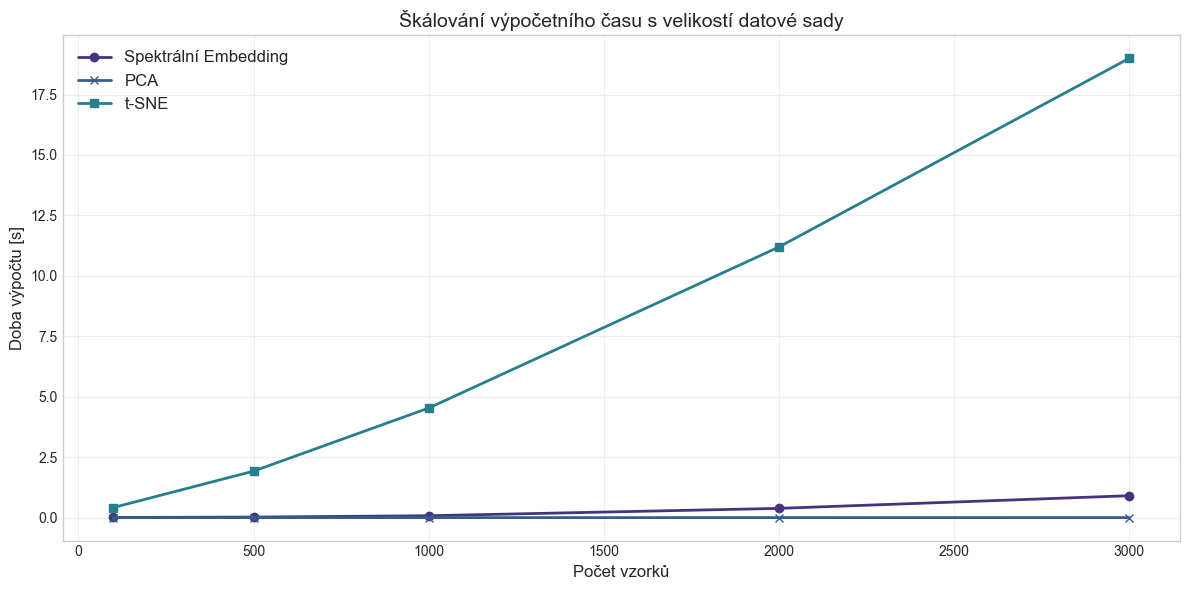

In [14]:
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, SpectralEmbedding

# Vytvoření syntetických datových sad různých velikostí
sample_sizes = [100, 500, 1000, 2000, 3000]
n_features = 20  # Počet příznaků
n_clusters = 3   # Počet shluků

times_spectral = []
times_pca = []
times_tsne = []

for n_samples in sample_sizes:
    # Vytvoření dat
    X, _ = make_blobs(n_samples=n_samples, n_features=n_features, 
                      centers=n_clusters, random_state=42)
    
    # Měření času pro Spektrální Embedding
    start_time = time.time()
    SpectralEmbedding(n_components=2, random_state=42).fit_transform(X)
    spectral_time = time.time() - start_time
    times_spectral.append(spectral_time)
    
    # Měření času pro PCA
    start_time = time.time()
    PCA(n_components=2, random_state=42).fit_transform(X)
    pca_time = time.time() - start_time
    times_pca.append(pca_time)
    
    # Měření času pro t-SNE
    start_time = time.time()
    TSNE(n_components=2, random_state=42).fit_transform(X)
    tsne_time = time.time() - start_time
    times_tsne.append(tsne_time)
    
    print(f"Velikost vzorku: {n_samples}, "
          f"Spektrální Embedding: {spectral_time:.4f}s, "
          f"PCA: {pca_time:.4f}s, "
          f"t-SNE: {tsne_time:.4f}s")

# Vizualizace výsledků
plt.figure(figsize=(12, 6))
plt.plot(sample_sizes, times_spectral, 'o-', linewidth=2, label='Spektrální Embedding')
plt.plot(sample_sizes, times_pca, 'x-', linewidth=2, label='PCA')
plt.plot(sample_sizes, times_tsne, 's-', linewidth=2, label='t-SNE')
plt.xlabel('Počet vzorků', fontsize=12)
plt.ylabel('Doba výpočtu [s]', fontsize=12)
plt.title('Škálování výpočetního času s velikostí datové sady', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 8. Shrnutí a doporučení pro Spektrální Embedding

### Výhody Spektrálního Embeddingu:

1. **Zachování nelineární struktury dat** - Dokáže odhalit komplexní, nelineární struktury, které lineární metody jako PCA nemohou zachytit
2. **Efektivní vizualizace** - Vhodná pro vizualizaci vysoko-dimenzionálních dat s nelineární strukturou
3. **Zachování lokální struktury** - Zaměřuje se na zachování lokálních sousedství bodů
4. **Grafově založený přístup** - Modeluje data jako graf, což umožňuje lepší pochopení souvislostí mezi body
5. **Robustnost** - Často poskytuje dobré výsledky i na komplikovaných datových strukturách jako Swiss Roll nebo S-křivka

### Nevýhody Spektrálního Embeddingu:

1. **Výpočetní náročnost** - Výrazně pomalejší než PCA, zejména pro velké datové sady
2. **Paměťová náročnost** - Konstruuje matici sousedství o velikosti O(n²), což může být problematické pro velké datové sady
3. **Citlivost na hyperparametry** - Výsledky mohou být silně ovlivněny volbou parametrů jako n_neighbors
4. **Nejednoznačná interpretace os** - Na rozdíl od PCA nemají výsledné osy jasnou interpretaci
5. **Problematické out-of-sample rozšíření** - Ne vždy je jednoduché aplikovat naučenou transformaci na nová data

### Doporučení pro použití:

- **Kdy použít Spektrální Embedding**:
  - Když máte důvod předpokládat, že data leží na nebo poblíž nelineární variety (manifold)
  - Pro vizualizaci komplexních, nelineárních dat
  - Když je důležité zachovat lokální strukturu dat
  - Jako předzpracování před aplikací shlukovacích algoritmů na nelineární data

- **Kdy zvážit jiné metody**:
  - Pro velmi velké datové sady (miliony vzorků) kvůli výpočetní náročnosti
  - Když je důležitá interpretovatelnost výsledných dimenzí (použijte PCA)
  - Když potřebujete jen rychlou vizualizaci dat (použijte PCA nebo UMAP)
  - Když potřebujete zachovat vzdálenosti mezi všemi body, i vzdálenými (použijte MDS)

- **Klíčové parametry k ladění**:
  - `n_neighbors`: Určuje velikost lokálního sousedství (typicky 5-50)
  - `affinity`: Typ podobnosti ('nearest_neighbors' nebo 'rbf')
  - `n_components`: Počet dimenzí výstupního prostoru (typicky 2 nebo 3 pro vizualizaci)

### Závěrečné shrnutí:

Spektrální Embedding je výkonná metoda nelineární redukce dimenzionality, která dokáže odhalit komplexní struktury v datech. Je obzvláště užitečná pro vizualizaci dat a jako přípravný krok před aplikací dalších algoritmů strojového učení. Nicméně, její výpočetní náročnost může být limitujícím faktorem pro velmi velké datové sady.